In [50]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from pathlib import Path

# Set display options
pd.set_option('display.max_columns', 50)
sns.set_theme(style='whitegrid')

# Load your salary data
df = pd.read_csv(Path.cwd().parent / "data" / "raw" / "salaries_raw.csv")

print(f"✅ Loaded: {df.shape}")
df.head()

✅ Loaded: (3755, 11)


,work_year,experience_level,employment_type,job_title,salary,salary_currency,salary_in_usd,employee_residence,remote_ratio,company_location,company_size
0,2023,SE,FT,Principal Data Scientist,80000,EUR,85847,ES,100,ES,L
1,2023,MI,CT,ML Engineer,30000,USD,30000,US,100,US,S
2,2023,MI,CT,ML Engineer,25500,USD,25500,US,100,US,S
3,2023,SE,FT,Data Scientist,175000,USD,175000,CA,100,CA,M
4,2023,SE,FT,Data Scientist,120000,USD,120000,CA,100,CA,M


In [51]:
print("DATASET INFO")
print("=" * 40)
df.info()

DATASET INFO
<class 'pandas.DataFrame'>
RangeIndex: 3755 entries, 0 to 3754
Data columns (total 11 columns):
 #   Column              Non-Null Count  Dtype
---  ------              --------------  -----
 0   work_year           3755 non-null   int64
 1   experience_level    3755 non-null   str  
 2   employment_type     3755 non-null   str  
 3   job_title           3755 non-null   str  
 4   salary              3755 non-null   int64
 5   salary_currency     3755 non-null   str  
 6   salary_in_usd       3755 non-null   int64
 7   employee_residence  3755 non-null   str  
 8   remote_ratio        3755 non-null   int64
 9   company_location    3755 non-null   str  
 10  company_size        3755 non-null   str  
dtypes: int64(4), str(7)
memory usage: 322.8 KB


In [52]:
print("COLUMN DATA TYPES")
print("=" * 40)
print(df.dtypes)
print(f"\nUnique dtypes: {df.dtypes.unique()}")

COLUMN DATA TYPES
work_year             int64
experience_level        str
employment_type         str
job_title               str
salary                int64
salary_currency         str
salary_in_usd         int64
employee_residence      str
remote_ratio          int64
company_location        str
company_size            str
dtype: object

Unique dtypes: [dtype('int64') <StringDtype(storage='python', na_value=nan)>]


In [53]:
print("DESCRIPTIVE STATISTICS")
print("=" * 40)
df.describe().T

DESCRIPTIVE STATISTICS


,count,mean,std,min,25%,50%,75%,max
work_year,3755.0,2022.373635,0.691448,2020.0,2022.0,2022.0,2023.0,2023.0
salary,3755.0,190695.571771,671676.500508,6000.0,100000.0,138000.0,180000.0,30400000.0
salary_in_usd,3755.0,137570.389880,63055.625278,5132.0,95000.0,135000.0,175000.0,450000.0
remote_ratio,3755.0,46.271638,48.589050,0.0,0.0,0.0,100.0,100.0


In [54]:
print("TARGET: salary_in_usd")
print("=" * 40)
print(f"Min: ${df['salary_in_usd'].min():,}")
print(f"Max: ${df['salary_in_usd'].max():,}")
print(f"Mean: ${df['salary_in_usd'].mean():,.2f}")
print(f"Median: ${df['salary_in_usd'].median():,.2f}")
print(f"Std: ${df['salary_in_usd'].std():,.2f}")
print(f"Skewness: {df['salary_in_usd'].skew():.2f}")

TARGET: salary_in_usd
Min: $5,132
Max: $450,000
Mean: $137,570.39
Median: $135,000.00
Std: $63,055.63
Skewness: 0.54


In [55]:
print("MISSING VALUES")
print("=" * 40)
missing = df.isnull().sum()
missing_pct = (df.isnull().mean() * 100).round(2)
missing_df = pd.DataFrame({'Count': missing, 'Percentage': missing_pct})
print(missing_df[missing_df['Count'] > 0] if missing.sum() > 0 else "✅ No missing values")

MISSING VALUES
✅ No missing values


In [56]:
print("DUPLICATE ROWS")
print("=" * 40)
dup_count = df.duplicated().sum()
print(f"Duplicate rows: {dup_count}")
print(f"Duplicate percentage: {dup_count / len(df) * 100:.2f}%")

DUPLICATE ROWS
Duplicate rows: 1171
Duplicate percentage: 31.19%


In [57]:
print("CATEGORICAL COLUMN VALUES")
print("=" * 40)

cat_cols = ['experience_level', 'employment_type', 'company_size', 'remote_ratio']
for col in cat_cols:
    print(f"\n{col}: {df[col].unique()}")
    print(f"  Counts:\n{df[col].value_counts()}")

CATEGORICAL COLUMN VALUES

experience_level: <StringArray>
['SE', 'MI', 'EN', 'EX']
Length: 4, dtype: str
  Counts:
experience_level
SE    2516
MI     805
EN     320
EX     114
Name: count, dtype: int64

employment_type: <StringArray>
['FT', 'CT', 'FL', 'PT']
Length: 4, dtype: str
  Counts:
employment_type
FT    3718
PT      17
CT      10
FL      10
Name: count, dtype: int64

company_size: <StringArray>
['L', 'S', 'M']
Length: 3, dtype: str
  Counts:
company_size
M    3153
L     454
S     148
Name: count, dtype: int64

remote_ratio: [100   0  50]
  Counts:
remote_ratio
0      1923
100    1643
50      189
Name: count, dtype: int64


In [58]:
print("JOB TITLE ANALYSIS")
print("=" * 40)
print(f"Unique job titles: {df['job_title'].nunique()}")
print(f"\nTop 15 most common:")
print(df['job_title'].value_counts().head(15))
print(f"\nBottom 5 least common:")
print(df['job_title'].value_counts().tail(5))

JOB TITLE ANALYSIS
Unique job titles: 93

Top 15 most common:
job_title
Data Engineer                 1040
Data Scientist                 840
Data Analyst                   612
Machine Learning Engineer      289
Analytics Engineer             103
Data Architect                 101
Research Scientist              82
Applied Scientist               58
Data Science Manager            58
Research Engineer               37
ML Engineer                     34
Data Manager                    29
Machine Learning Scientist      26
Data Science Consultant         24
Data Analytics Manager          22
Name: count, dtype: int64

Bottom 5 least common:
job_title
Principal Data Architect    1
Cloud Data Architect        1
Head of Machine Learning    1
Staff Data Scientist        1
Finance Data Analyst        1
Name: count, dtype: int64


DISTRIBUTION HISTOGRAMS


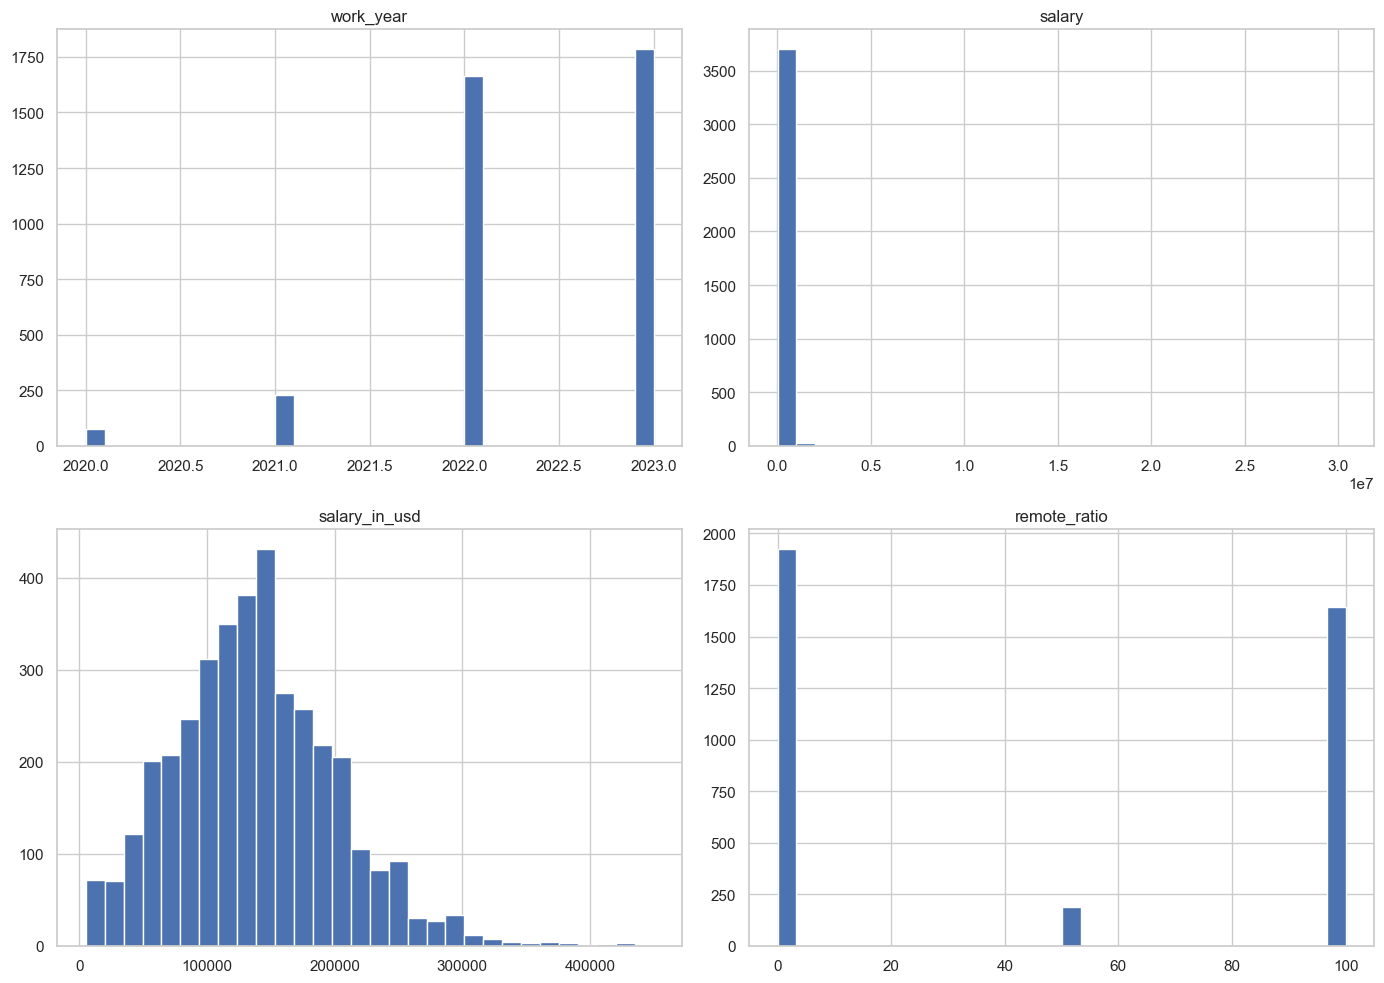

In [59]:
print("DISTRIBUTION HISTOGRAMS")
print("=" * 40)
df.hist(figsize=(14, 10), bins=30)
plt.tight_layout()
plt.show()

In [60]:
print("FEATURE SKEWNESS")
print("=" * 40)
numeric_cols = df.select_dtypes(include=[np.number]).columns
skewness = df[numeric_cols].skew().sort_values(ascending=False)
print(skewness.round(3))

FEATURE SKEWNESS
salary           28.938
salary_in_usd     0.536
remote_ratio      0.149
work_year        -1.016
dtype: float64


BOXPLOTS - OUTLIER DETECTION


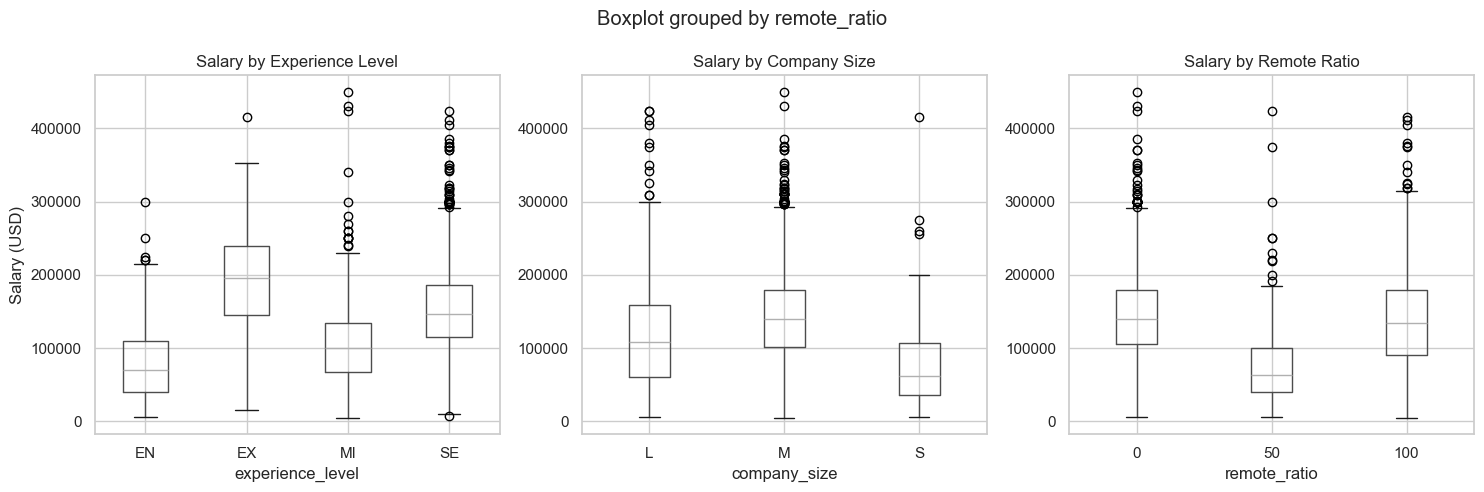

In [62]:
print("BOXPLOTS - OUTLIER DETECTION")
print("=" * 40)
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Salary by experience
df.boxplot(column='salary_in_usd', by='experience_level', ax=axes[0])
axes[0].set_title('Salary by Experience Level')
axes[0].set_ylabel('Salary (USD)')

# Salary by company size
df.boxplot(column='salary_in_usd', by='company_size', ax=axes[1])
axes[1].set_title('Salary by Company Size')

# Salary by remote ratio
df.boxplot(column='salary_in_usd', by='remote_ratio', ax=axes[2])
axes[2].set_title('Salary by Remote Ratio')

plt.tight_layout()
plt.show()

In [63]:
print("CORRELATION WITH TARGET")
print("=" * 40)

# Encode categorical for correlation
df_corr = df.copy()
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
df_corr['experience_level'] = le.fit_transform(df_corr['experience_level'])
df_corr['employment_type'] = le.fit_transform(df_corr['employment_type'])
df_corr['company_size'] = le.fit_transform(df_corr['company_size'])

numeric_df = df_corr.select_dtypes(include=[np.number])
corr = numeric_df.corr()
corr_with_target = corr[['salary_in_usd']].sort_values(by='salary_in_usd', ascending=False)
print(corr_with_target)

CORRELATION WITH TARGET
                  salary_in_usd
salary_in_usd          1.000000
experience_level       0.327173
work_year              0.228290
company_size          -0.000372
employment_type       -0.010329
salary                -0.023676
remote_ratio          -0.064171


CORRELATION HEATMAP


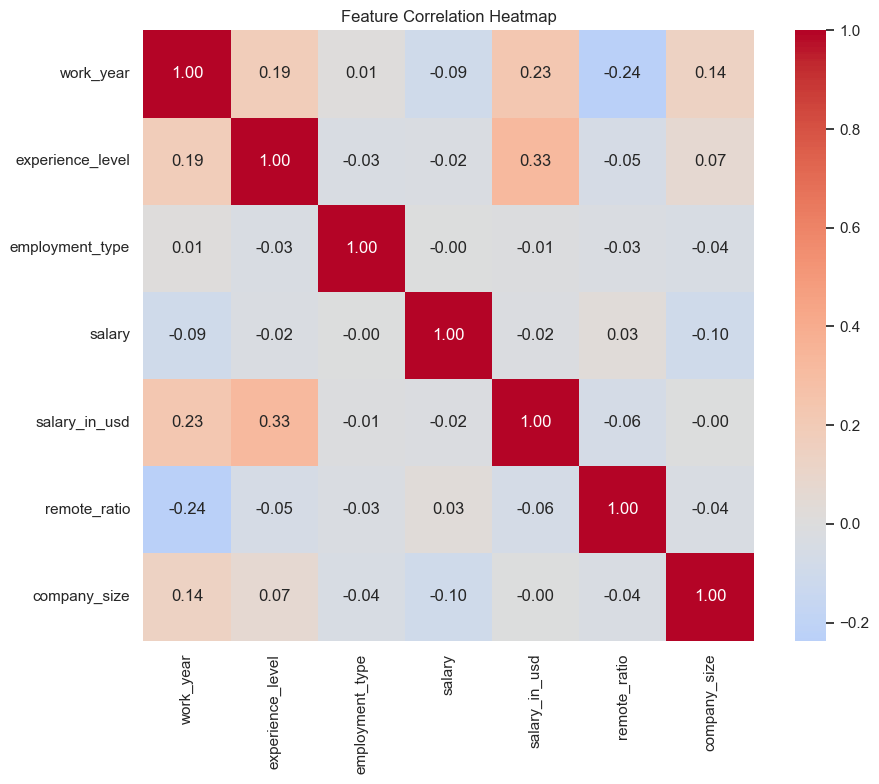

In [64]:
print("CORRELATION HEATMAP")
print("=" * 40)
plt.figure(figsize=(10, 8))
sns.heatmap(corr, cmap='coolwarm', center=0, annot=True, fmt='.2f', square=True)
plt.title('Feature Correlation Heatmap')
plt.tight_layout()
plt.show()

SALARY BY EXPERIENCE LEVEL
                       Mean    Median    Min     Max  Count
experience_level                                           
EN                 78546.28   70000.0   5409  300000    320
EX                194930.93  196000.0  15000  416000    114
MI                104525.94  100000.0   5132  450000    805
SE                153051.07  146000.0   8000  423834   2516


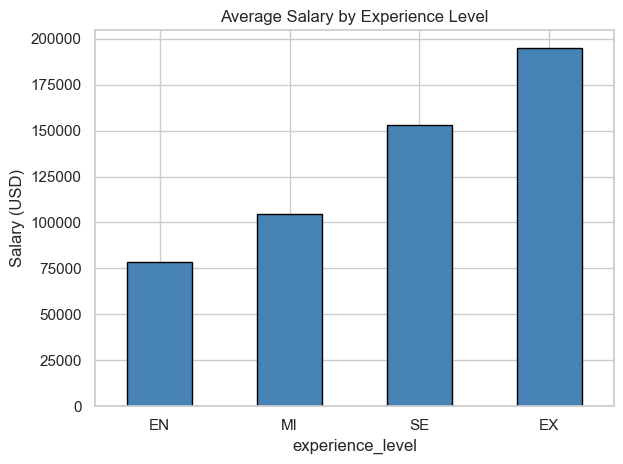

In [65]:
print("SALARY BY EXPERIENCE LEVEL")
print("=" * 40)
exp_stats = df.groupby('experience_level')['salary_in_usd'].agg([
    ('Mean', 'mean'),
    ('Median', 'median'),
    ('Min', 'min'),
    ('Max', 'max'),
    ('Count', 'count')
]).round(2)
print(exp_stats)

# Bar plot
exp_stats['Mean'].sort_values().plot(kind='bar', color='steelblue', edgecolor='black')
plt.title('Average Salary by Experience Level')
plt.ylabel('Salary (USD)')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [66]:
print("SALARY BY COMPANY SIZE")
print("=" * 40)
size_stats = df.groupby('company_size')['salary_in_usd'].agg([
    ('Mean', 'mean'),
    ('Median', 'median'),
    ('Min', 'min'),
    ('Max', 'max'),
    ('Count', 'count')
]).round(2)
print(size_stats)

SALARY BY COMPANY SIZE
                   Mean    Median   Min     Max  Count
company_size                                          
L             118300.98  108500.0  5409  423834    454
M             143130.55  140000.0  5132  450000   3153
S              78226.68   62146.0  5679  416000    148


In [67]:
print("SALARY BY COMPANY SIZE")
print("=" * 40)
size_stats = df.groupby('company_size')['salary_in_usd'].agg([
    ('Mean', 'mean'),
    ('Median', 'median'),
    ('Min', 'min'),
    ('Max', 'max'),
    ('Count', 'count')
]).round(2)
print(size_stats)

SALARY BY COMPANY SIZE
                   Mean    Median   Min     Max  Count
company_size                                          
L             118300.98  108500.0  5409  423834    454
M             143130.55  140000.0  5132  450000   3153
S              78226.68   62146.0  5679  416000    148


In [68]:
print("SALARY BY EMPLOYMENT TYPE")
print("=" * 40)
emp_stats = df.groupby('employment_type')['salary_in_usd'].agg([
    ('Mean', 'mean'),
    ('Median', 'median'),
    ('Count', 'count')
]).round(2)
print(emp_stats)

SALARY BY EMPLOYMENT TYPE
                      Mean    Median  Count
employment_type                            
CT               113446.90   75000.0     10
FL                51807.80   50000.0     10
FT               138314.20  135000.0   3718
PT                39533.71   21669.0     17


In [69]:
print("SALARY BY REMOTE RATIO")
print("=" * 40)
remote_stats = df.groupby('remote_ratio')['salary_in_usd'].agg([
    ('Mean', 'mean'),
    ('Median', 'median'),
    ('Count', 'count')
]).round(2)
print(remote_stats)

SALARY BY REMOTE RATIO
                   Mean    Median  Count
remote_ratio                            
0             144316.20  139600.0   1923
50             78400.69   63312.0    189
100           136481.45  135000.0   1643


SALARY BY EXPERIENCE × COMPANY SIZE
company_size              L          M          S
experience_level                                 
EN                 72896.81   87416.46   59120.73
EX                165363.15  198857.28  196827.17
MI                 89135.73  111586.42   58080.50
SE                156159.69  153643.33  106875.47


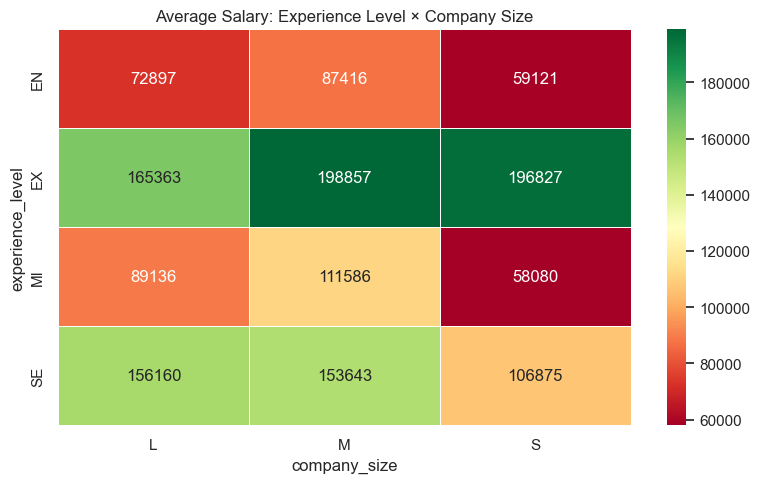

In [70]:
print("SALARY BY EXPERIENCE × COMPANY SIZE")
print("=" * 40)
pivot = df.pivot_table(
    values='salary_in_usd',
    index='experience_level',
    columns='company_size',
    aggfunc='mean'
).round(2)
print(pivot)

# Heatmap
plt.figure(figsize=(8, 5))
sns.heatmap(pivot, annot=True, fmt='.0f', cmap='RdYlGn', linewidths=0.5)
plt.title('Average Salary: Experience Level × Company Size')
plt.tight_layout()
plt.show()

TOP 10 HIGHEST PAID JOB TITLES
job_title
Data Science Tech Lead                375000.000000
Cloud Data Architect                  250000.000000
Data Lead                             212500.000000
Data Analytics Lead                   211254.500000
Principal Data Scientist              198171.125000
Director of Data Science              195140.727273
Principal Data Engineer               192500.000000
Machine Learning Software Engineer    192420.000000
Data Science Manager                  191278.775862
Applied Scientist                     190264.482759
Name: salary_in_usd, dtype: float64


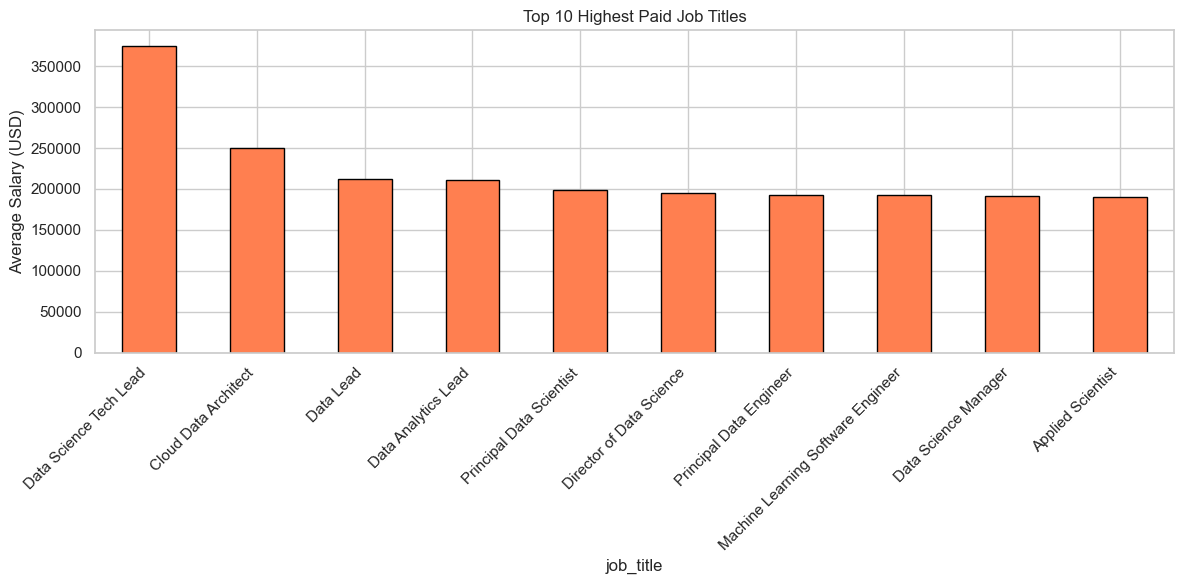

In [71]:
print("TOP 10 HIGHEST PAID JOB TITLES")
print("=" * 40)
top_jobs = df.groupby('job_title')['salary_in_usd'].mean().sort_values(ascending=False).head(10)
print(top_jobs)

# Bar plot
top_jobs.plot(kind='bar', figsize=(12, 6), color='coral', edgecolor='black')
plt.title('Top 10 Highest Paid Job Titles')
plt.ylabel('Average Salary (USD)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [72]:
print("EXPERIENCE LEVEL DISTRIBUTION")
print("=" * 40)
print(df['experience_level'].value_counts())
print("\nNormalized (%):")
print(df['experience_level'].value_counts(normalize=True).round(3) * 100)

EXPERIENCE LEVEL DISTRIBUTION
experience_level
SE    2516
MI     805
EN     320
EX     114
Name: count, dtype: int64

Normalized (%):
experience_level
SE    67.0
MI    21.4
EN     8.5
EX     3.0
Name: proportion, dtype: float64


In [73]:
print("SALARY QUANTILES")
print("=" * 40)
quantiles = df['salary_in_usd'].quantile([0.1, 0.25, 0.5, 0.75, 0.9, 0.95, 0.99])
print(quantiles)

# Create salary bands
df['salary_band'] = pd.cut(
    df['salary_in_usd'],
    bins=[0, 50000, 100000, 150000, 200000, 500000],
    labels=['<50K', '50-100K', '100-150K', '150-200K', '200K+']
)
print("\nSalary band distribution:")
print(df['salary_band'].value_counts().sort_index())

SALARY QUANTILES
0.10     59537.0
0.25     95000.0
0.50    135000.0
0.75    175000.0
0.90    219000.0
0.95    249360.0
0.99    309400.0
Name: salary_in_usd, dtype: float64

Salary band distribution:
salary_band
<50K         287
50-100K      803
100-150K    1262
150-200K     872
200K+        531
Name: count, dtype: int64


In [74]:
print("OUTLIER DETECTION (IQR Method)")
print("=" * 40)
Q1 = df['salary_in_usd'].quantile(0.25)
Q3 = df['salary_in_usd'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = df[(df['salary_in_usd'] < lower_bound) | (df['salary_in_usd'] > upper_bound)]
print(f"Lower bound: ${lower_bound:,.2f}")
print(f"Upper bound: ${upper_bound:,.2f}")
print(f"Number of outliers: {len(outliers)}")
print(f"Outlier percentage: {len(outliers) / len(df) * 100:.2f}%")
print(f"\nOutlier salary range: ${outliers['salary_in_usd'].min():,.2f} - ${outliers['salary_in_usd'].max():,.2f}")

OUTLIER DETECTION (IQR Method)
Lower bound: $-25,000.00
Upper bound: $295,000.00
Number of outliers: 63
Outlier percentage: 1.68%

Outlier salary range: $297,300.00 - $450,000.00


SALARY TREND BY YEAR
                mean    median  count
work_year                            
2020        92302.63   73065.0     76
2021        94087.21   80000.0    230
2022       133338.62  131300.0   1664
2023       149045.54  143860.0   1785


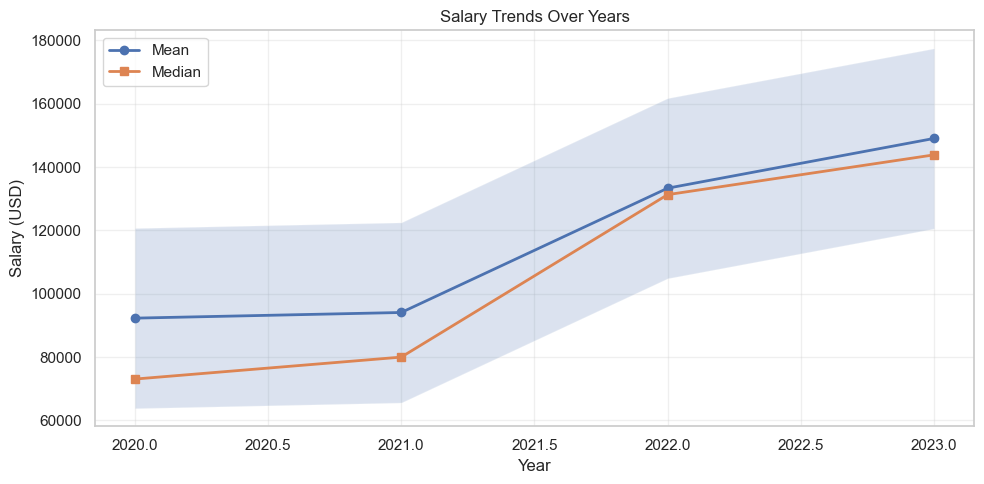

In [75]:
print("SALARY TREND BY YEAR")
print("=" * 40)
yearly = df.groupby('work_year')['salary_in_usd'].agg(['mean', 'median', 'count']).round(2)
print(yearly)

# Line plot
plt.figure(figsize=(10, 5))
plt.plot(yearly.index, yearly['mean'], marker='o', linewidth=2, label='Mean')
plt.plot(yearly.index, yearly['median'], marker='s', linewidth=2, label='Median')
plt.fill_between(yearly.index, yearly['mean'] - yearly['mean'].std(), 
                 yearly['mean'] + yearly['mean'].std(), alpha=0.2)
plt.title('Salary Trends Over Years')
plt.xlabel('Year')
plt.ylabel('Salary (USD)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

CROSS-TABULATION: Experience × Remote Ratio
remote_ratio            0          50         100
experience_level                                 
EN                104581.77   64006.23   65040.49
EX                182435.79  139030.17  214837.33
MI                116723.10   74214.41   96803.48
SE                154024.06   98438.14  154022.02


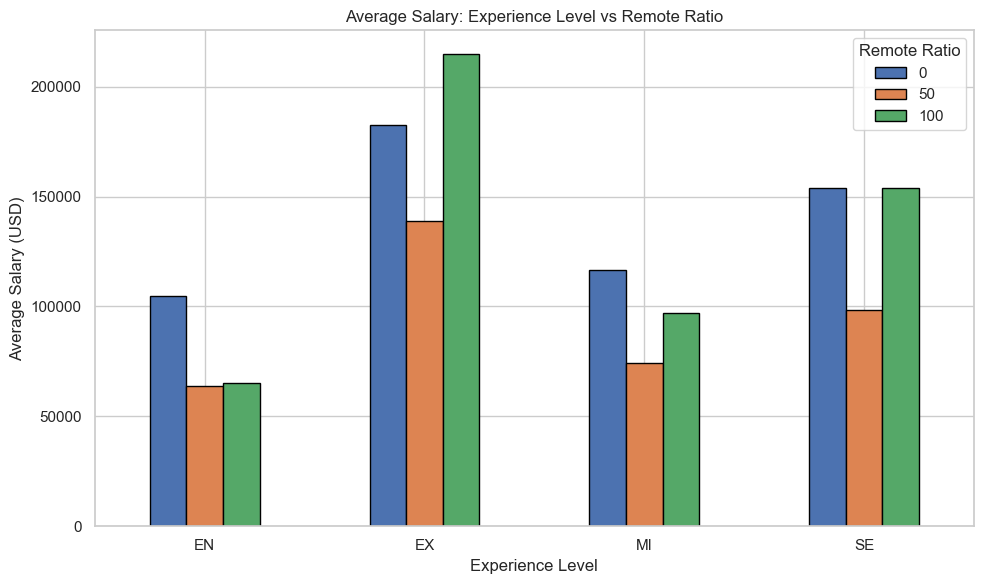

In [76]:
print("CROSS-TABULATION: Experience × Remote Ratio")
print("=" * 40)
cross_tab = pd.crosstab(df['experience_level'], df['remote_ratio'], 
                         values=df['salary_in_usd'], aggfunc='mean').round(2)
print(cross_tab)

# Stacked bar chart
cross_tab.plot(kind='bar', stacked=False, figsize=(10, 6), edgecolor='black')
plt.title('Average Salary: Experience Level vs Remote Ratio')
plt.xlabel('Experience Level')
plt.ylabel('Average Salary (USD)')
plt.legend(title='Remote Ratio')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [77]:
print("=" * 50)
print("EDA SUMMARY - Key Takeaways for Encoding")
print("=" * 50)

print(f"""
1. experience_level mapping: EN→0, MI→1, SE→2, EX→3
   Values found: {df['experience_level'].unique()}

2. employment_type mapping: FT→0, PT→1, CT→2, FL→3
   Values found: {df['employment_type'].unique()}

3. company_size mapping: S→0, M→1, L→2
   Values found: {df['company_size'].unique()}

4. remote_ratio: Keep as is (0, 50, 100)

5. job_title: {df['job_title'].nunique()} unique values → Use frequency encoding

6. Missing values: {df.isnull().sum().sum()}

7. Target range: ${df['salary_in_usd'].min():,} - ${df['salary_in_usd'].max():,}
""")

# Clean up temporary columns
df = df.drop('salary_band', axis=1, errors='ignore')

EDA SUMMARY - Key Takeaways for Encoding

1. experience_level mapping: EN→0, MI→1, SE→2, EX→3
   Values found: <StringArray>
['SE', 'MI', 'EN', 'EX']
Length: 4, dtype: str

2. employment_type mapping: FT→0, PT→1, CT→2, FL→3
   Values found: <StringArray>
['FT', 'CT', 'FL', 'PT']
Length: 4, dtype: str

3. company_size mapping: S→0, M→1, L→2
   Values found: <StringArray>
['L', 'S', 'M']
Length: 3, dtype: str

4. remote_ratio: Keep as is (0, 50, 100)

5. job_title: 93 unique values → Use frequency encoding

6. Missing values: 0

7. Target range: $5,132 - $450,000



In [78]:
print("=" * 50)
print("FINAL EDA SUMMARY - All Key Findings")
print("=" * 50)

summary = f"""
DATASET: {df.shape[0]} rows, {df.shape[1]} columns

TARGET: salary_in_usd
- Range: ${df['salary_in_usd'].min():,} - ${df['salary_in_usd'].max():,}
- Mean: ${df['salary_in_usd'].mean():,.2f}
- Median: ${df['salary_in_usd'].median():,.2f}
- Skewness: {df['salary_in_usd'].skew():.2f}

QUALITY:
- Missing values: {df.isnull().sum().sum()}
- Duplicate rows: {dup_count} ({dup_count/len(df)*100:.2f}%)
- Outliers (IQR): {len(outliers)} ({len(outliers)/len(df)*100:.2f}%)

ENCODING PLAN:
- experience_level: {df['experience_level'].nunique()} values → Ordinal (EN=0, MI=1, SE=2, EX=3)
- employment_type: {df['employment_type'].nunique()} values → Ordinal (FT=0, PT=1, CT=2, FL=3)
- company_size: {df['company_size'].nunique()} values → Ordinal (S=0, M=1, L=2)
- job_title: {df['job_title'].nunique()} values → Frequency encoding
- remote_ratio: {df['remote_ratio'].nunique()} values → Keep as numeric

TOP 3 HIGHEST PAID TITLES:
{df.groupby('job_title')['salary_in_usd'].mean().sort_values(ascending=False).head(3).to_string()}

STRONGEST CORRELATIONS WITH TARGET:
{corr_with_target.head(3).to_string()}
"""

print(summary)

FINAL EDA SUMMARY - All Key Findings

DATASET: 3755 rows, 11 columns

TARGET: salary_in_usd
- Range: $5,132 - $450,000
- Mean: $137,570.39
- Median: $135,000.00
- Skewness: 0.54

QUALITY:
- Missing values: 0
- Duplicate rows: 1171 (31.19%)
- Outliers (IQR): 63 (1.68%)

ENCODING PLAN:
- experience_level: 4 values → Ordinal (EN=0, MI=1, SE=2, EX=3)
- employment_type: 4 values → Ordinal (FT=0, PT=1, CT=2, FL=3)
- company_size: 3 values → Ordinal (S=0, M=1, L=2)
- job_title: 93 values → Frequency encoding
- remote_ratio: 3 values → Keep as numeric

TOP 3 HIGHEST PAID TITLES:
job_title
Data Science Tech Lead    375000.0
Cloud Data Architect      250000.0
Data Lead                 212500.0

STRONGEST CORRELATIONS WITH TARGET:
                  salary_in_usd
salary_in_usd          1.000000
experience_level       0.327173
work_year              0.228290

